# Bài Lab: U-Net Demo với Dữ Liệu Tổng Hợp

## Phần 1: Setup và Tạo Dữ Liệu Demo (15 phút)

In [ ]:
# ===== SETUP Cơ BẢN =====
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")


TensorFlow version: 2.20.0


In [ ]:
# ===== TẠO DỮ LIỆU DEMO =====
def create_synthetic_data(num_samples=500, img_size=64):
    """Tạo dữ liệu tổng hợp: hình tròn, vuông, tam giác"""
    images = []
    masks = []

    for i in range(num_samples):
        # Tạo ảnh trống
        img = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        mask = np.zeros((img_size, img_size), dtype=np.uint8)

        # Random shape type
        shape_type = np.random.choice(['circle', 'square', 'triangle'])

        # Random position và size
        center_x = np.random.randint(15, img_size-15)
        center_y = np.random.randint(15, img_size-15)
        size = np.random.randint(8, 20)

        # Random color
        color = tuple(np.random.randint(50, 255, 3).tolist())

        if shape_type == 'circle':
            cv2.circle(img, (center_x, center_y), size, color, -1)
            cv2.circle(mask, (center_x, center_y), size, 255, -1)

        elif shape_type == 'square':
            cv2.rectangle(img, (center_x-size, center_y-size),
                         (center_x+size, center_y+size), color, -1)
            cv2.rectangle(mask, (center_x-size, center_y-size),
                         (center_x+size, center_y+size), 255, -1)

        else:  # triangle
            pts = np.array([[center_x, center_y-size],
                           [center_x-size, center_y+size],
                           [center_x+size, center_y+size]], np.int32)
            cv2.fillPoly(img, [pts], color)
            cv2.fillPoly(mask, [pts], 255)

        # Normalize
        img = img.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)


Đang tạo dữ liệu demo...
Dataset shape: X=(500, 64, 64, 3), y=(500, 64, 64)


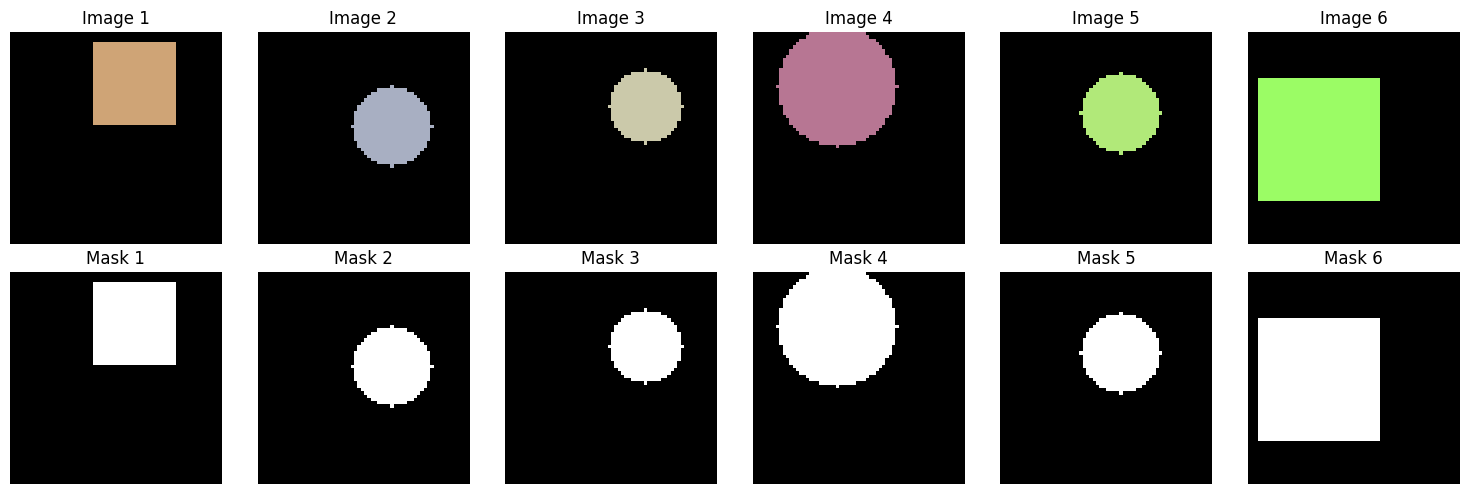

In [ ]:
# Tạo dataset
print("Đang tạo dữ liệu demo...")
X, y = create_synthetic_data(num_samples=500, img_size=64)
print(f"Dataset shape: X={X.shape}, y={y.shape}")

# Hiển thị mẫu
def show_samples(X, y, num_samples=6):
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 5))

    for i in range(num_samples):
        # Ảnh gốc
        axes[0, i].imshow(X[i])
        axes[0, i].set_title(f'Image {i+1}')
        axes[0, i].axis('off')

        # Mask
        axes[1, i].imshow(y[i], cmap='gray')
        axes[1, i].set_title(f'Mask {i+1}')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()

show_samples(X, y)


## Phần 2: Xây Dựng U-Net Đơn Giản (20 phút)

In [ ]:
def simple_unet(input_size=(64, 64, 3)):
    """U-Net đơn giản cho demo"""
    inputs = Input(input_size)

    # Encoder
    c1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D(2)(c1)

    c2 = Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D(2)(c2)

    c3 = Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(128, 3, activation='relu', padding='same')(c3)
    p3 = MaxPooling2D(2)(c3)

    # Bottleneck
    c4 = Conv2D(256, 3, activation='relu', padding='same')(p3)
    c4 = Conv2D(256, 3, activation='relu', padding='same')(c4)

    # Decoder
    u5 = Conv2DTranspose(128, 2, strides=2, padding='same')(c4)
    u5 = concatenate([u5, c3])
    c5 = Conv2D(128, 3, activation='relu', padding='same')(u5)
    c5 = Conv2D(128, 3, activation='relu', padding='same')(c5)

    u6 = Conv2DTranspose(64, 2, strides=2, padding='same')(c5)
    u6 = concatenate([u6, c2])
    c6 = Conv2D(64, 3, activation='relu', padding='same')(u6)
    c6 = Conv2D(64, 3, activation='relu', padding='same')(c6)

    u7 = Conv2DTranspose(32, 2, strides=2, padding='same')(c6)
    u7 = concatenate([u7, c1])
    c7 = Conv2D(32, 3, activation='relu', padding='same')(u7)
    c7 = Conv2D(32, 3, activation='relu', padding='same')(c7)

    # Output
    outputs = Conv2D(1, 1, activation='sigmoid')(c7)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model



In [ ]:
# Tạo model
model = simple_unet()
model.compile(optimizer=Adam(1e-3),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Hiển thị thông tin
print("Model U-Net Demo đã tạo xong!")
print(f"Tổng parameters: {model.count_params():,}")
model.summary()


Model U-Net Demo đã tạo xong!
Tổng parameters: 1,925,601


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 16,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 128) │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 8, 8, 256) │    295,168 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 8, 8, 256) │    590,080 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │    131,200 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │    295,040 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 32, 32,    │     32,832 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,925,601 (7.35 MB)

 Trainable params: 1,925,601 (7.35 MB)

 Non-trainable params: 0 (0.00 B)

## Phần 3: Training Nhanh (20 phút)

In [ ]:
# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Expand dims cho mask
y_train = np.expand_dims(y_train, axis=-1)
y_test = np.expand_dims(y_test, axis=-1)

# Training với epochs ít để nhanh
print("Bắt đầu training...")

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=15,  # Ít epochs để nhanh
    validation_data=(X_test, y_test),
    verbose=1
)

print("Training hoàn thành!")


Train: (400, 64, 64, 3), Test: (100, 64, 64, 3)
Bắt đầu training...
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9022 - loss: 0.5878 - val_accuracy: 0.9914 - val_loss: 0.3060
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9762 - loss: 0.1130 - val_accuracy: 0.9893 - val_loss: 0.0266
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9895 - loss: 0.0271 - val_accuracy: 0.9943 - val_loss: 0.0169
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9952 - loss: 0.0134 - val_accuracy: 0.9967 - val_loss: 0.0099
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9975 - loss: 0.0081 - val_accuracy: 0.9983 - val_loss: 0.0062
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9985 - loss: 0.0052 - val_accuracy: 0.9988 - val_loss: 0.0040
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9990 - loss: 0.0033 - val_accuracy: 0.9992 - val_loss: 0.0025
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37m

## Phần 4: Đánh Giá và Visualization (20 phút)

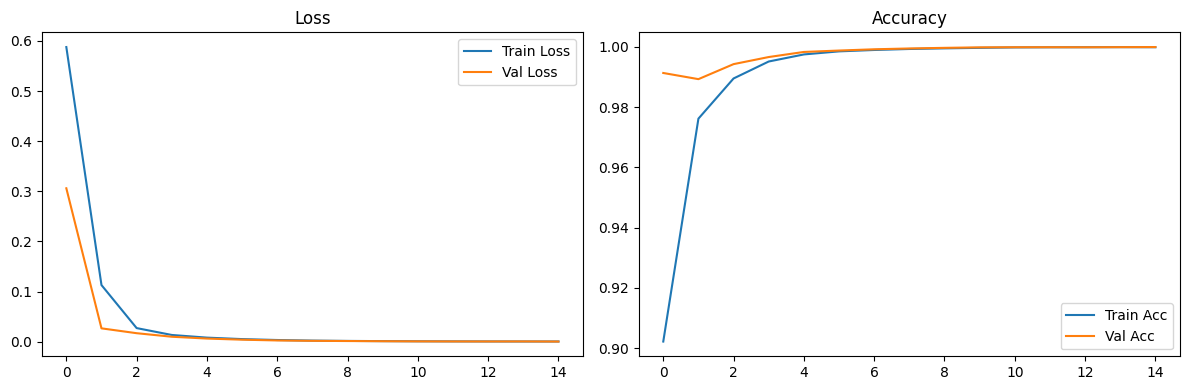

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


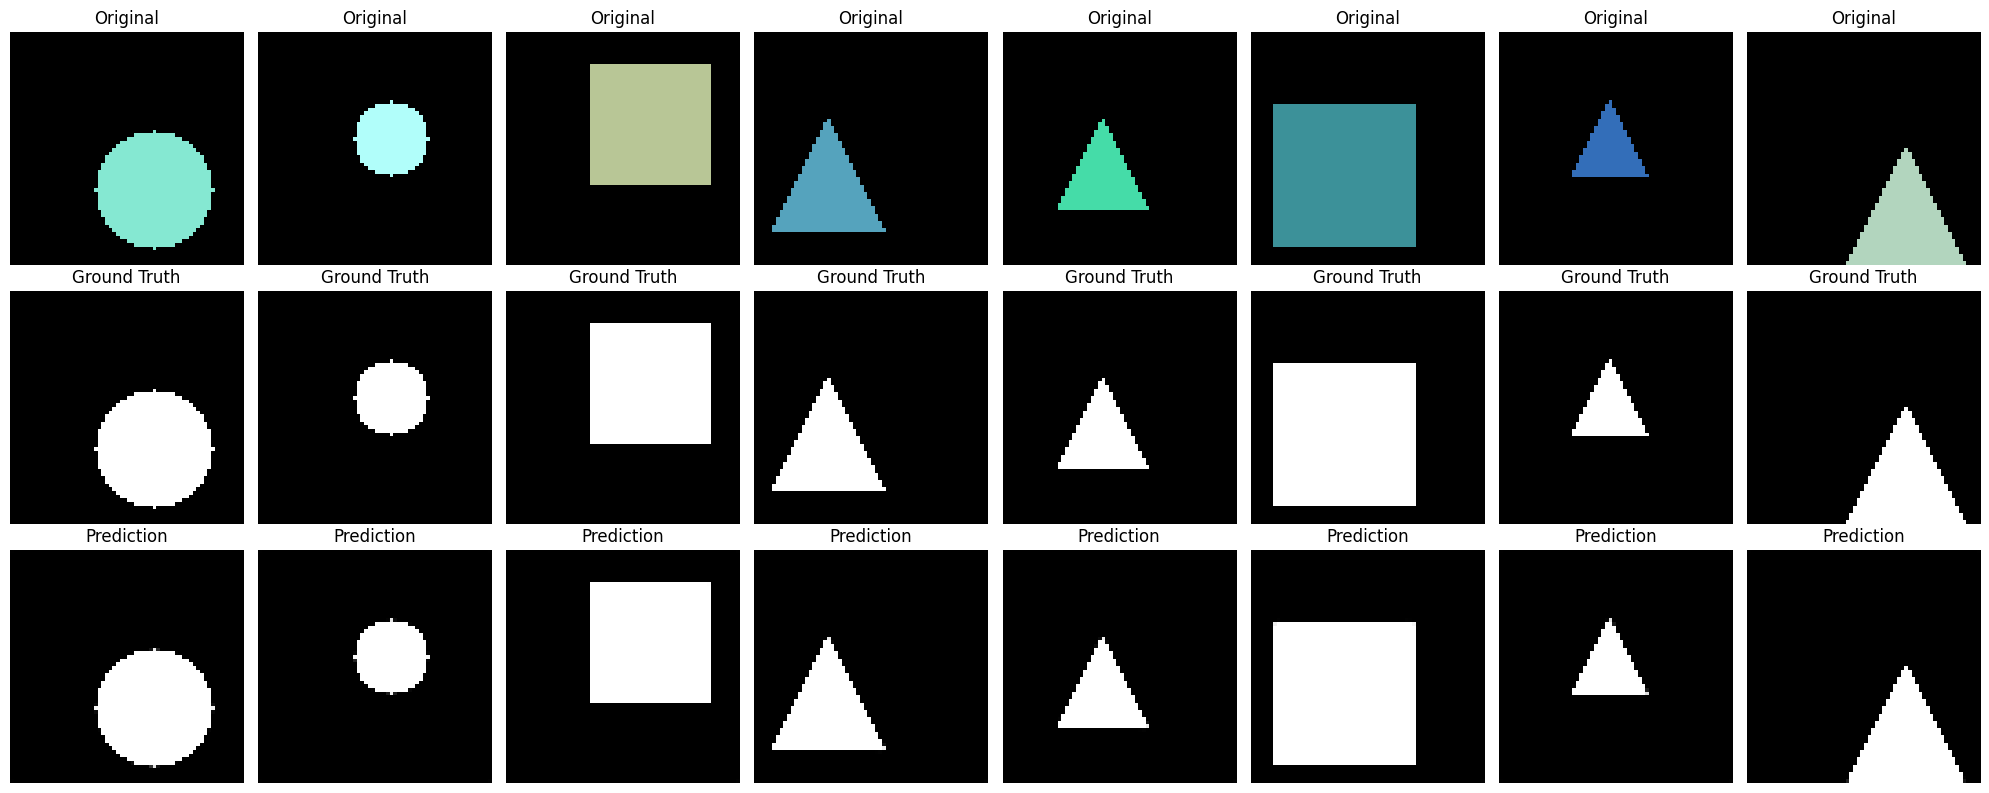

In [ ]:
# Plot training history
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

# Predict và hiển thị kết quả
def show_predictions(model, X_test, y_test, num_samples=8):
    predictions = model.predict(X_test[:num_samples])

    fig, axes = plt.subplots(3, num_samples, figsize=(20, 8))

    for i in range(num_samples):
        # Ảnh gốc
        axes[0, i].imshow(X_test[i])
        axes[0, i].set_title('Original')
        axes[0, i].axis('off')

        # Ground truth
        axes[1, i].imshow(y_test[i].squeeze(), cmap='gray')
        axes[1, i].set_title('Ground Truth')
        axes[1, i].axis('off')

        # Prediction
        pred = predictions[i].squeeze()
        axes[2, i].imshow(pred, cmap='gray')
        axes[2, i].set_title(f'Prediction')
        axes[2, i].axis('off')

    plt.tight_layout()
    plt.show()

show_predictions(model, X_test, y_test)


In [ ]:
# Tính IoU
def calculate_iou(y_true, y_pred, threshold=0.5):
    y_pred_binary = (y_pred > threshold).astype(np.float32)

    intersection = np.sum(y_true * y_pred_binary, axis=(1, 2))
    union = np.sum(y_true, axis=(1, 2)) + np.sum(y_pred_binary, axis=(1, 2)) - intersection

    iou = intersection / (union + 1e-7)
    return np.mean(iou)

test_predictions = model.predict(X_test)
iou_score = calculate_iou(y_test.squeeze(), test_predictions.squeeze())

print(f"IoU Score: {iou_score:.4f}")
print(f"Test Accuracy: {model.evaluate(X_test, y_test, verbose=0)[1]:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 220ms/step
IoU Score: 0.9998
Test Accuracy: 1.0000


## Phần 5: Bài Tập Thực Hành (15 phút)

In [ ]:
# ===== BÀI TẬP 1: Thử nghiệm threshold =====
print("Bài tập 1: Thử nghiệm threshold")
thresholds = [0.3, 0.5, 0.7, 0.9]
for thresh in thresholds:
    iou = calculate_iou(y_test.squeeze(), test_predictions.squeeze(), thresh)
    print(f"Threshold {thresh}: IoU = {iou:.4f}")



Bài tập 1: Thử nghiệm threshold
Threshold 0.3: IoU = 0.9998
Threshold 0.5: IoU = 0.9998
Threshold 0.7: IoU = 0.9995
Threshold 0.9: IoU = 0.9975



🔧 Bài tập 2: Test với dữ liệu mới
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
IoU trên dữ liệu mới: 0.9998
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


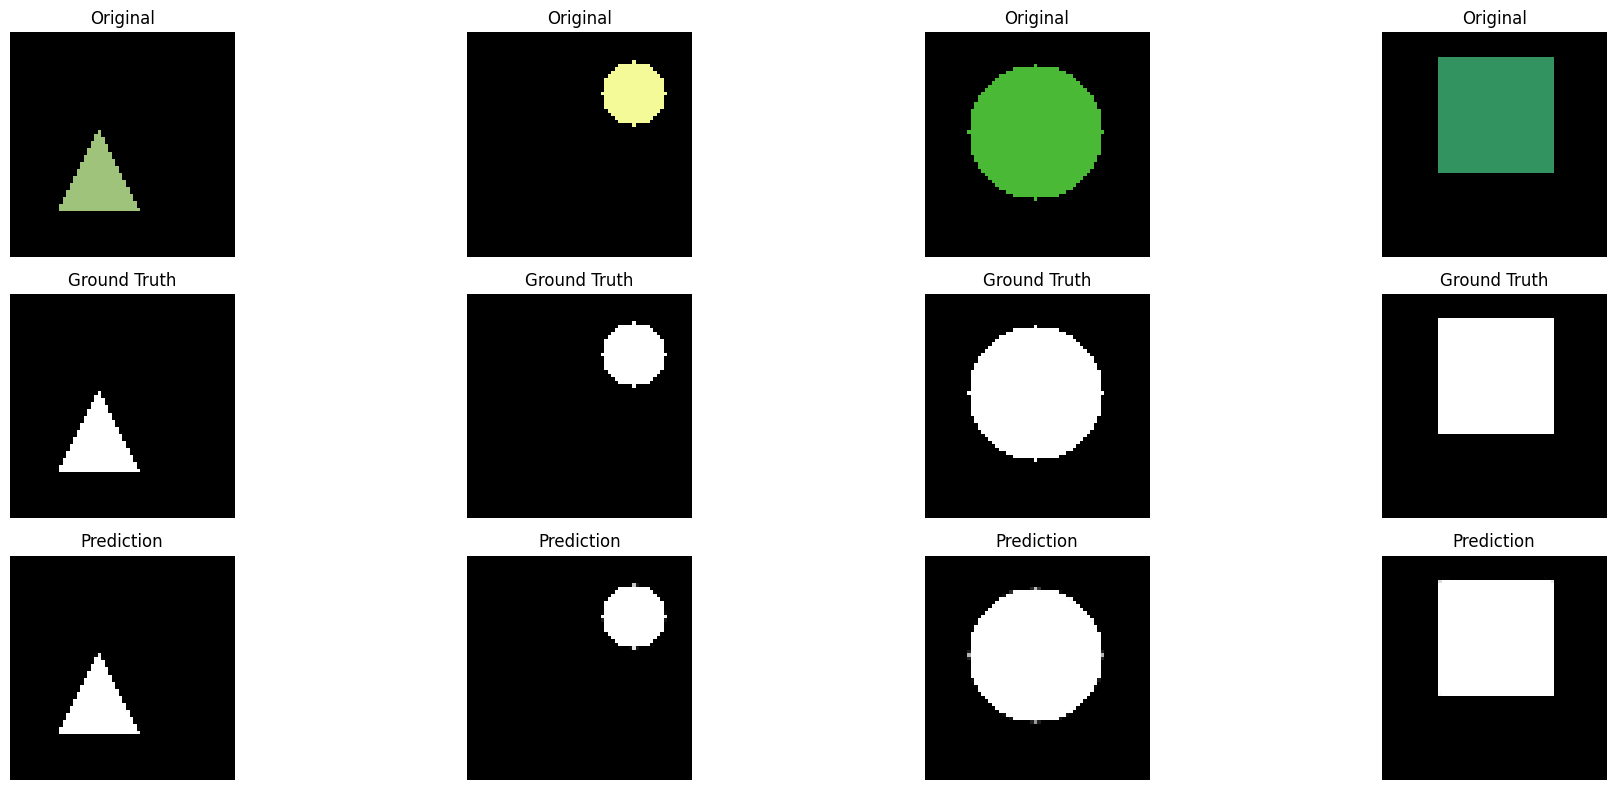

In [ ]:
# ===== BÀI TẬP 2: Tạo dữ liệu mới =====
print("\n🔧 Bài tập 2: Test với dữ liệu mới")
# TODO: Sinh viên tự tạo 50 ảnh mới và test

X_new, y_new = create_synthetic_data(num_samples=50, img_size=64)
y_new = np.expand_dims(y_new, axis=-1)

new_predictions = model.predict(X_new)
new_iou = calculate_iou(y_new.squeeze(), new_predictions.squeeze())
print(f"IoU trên dữ liệu mới: {new_iou:.4f}")

# Hiển thị một vài mẫu mới
show_predictions(model, X_new, y_new, num_samples=4)


In [ ]:
# ===== BÀI TẬP 3: So sánh model nhỏ hơn =====
print("\n Bài tập 3: Model nhỏ hơn")
def tiny_unet(input_size=(64, 64, 3)):
    """U-Net rất nhỏ"""
    inputs = Input(input_size)

    # Encoder
    c1 = Conv2D(16, 3, activation='relu', padding='same')(inputs)
    p1 = MaxPooling2D(2)(c1)

    c2 = Conv2D(32, 3, activation='relu', padding='same')(p1)
    p2 = MaxPooling2D(2)(c2)

    # Bottleneck
    c3 = Conv2D(64, 3, activation='relu', padding='same')(p2)

    # Decoder
    u4 = Conv2DTranspose(32, 2, strides=2, padding='same')(c3)
    u4 = concatenate([u4, c2])
    c4 = Conv2D(32, 3, activation='relu', padding='same')(u4)

    u5 = Conv2DTranspose(16, 2, strides=2, padding='same')(c4)
    u5 = concatenate([u5, c1])
    c5 = Conv2D(16, 3, activation='relu', padding='same')(u5)

    outputs = Conv2D(1, 1, activation='sigmoid')(c5)

    return Model(inputs=[inputs], outputs=[outputs])



 Bài tập 3: Model nhỏ hơn


In [ ]:
# 1. Khởi tạo và compile model tiny_unet
tiny_model = tiny_unet()
tiny_model.compile(
    optimizer=Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Mô hình Tiny U-Net đã được cấu hình thành công!")
print(f"Số lượng tham số của Tiny U-Net: {tiny_model.count_params():,}")
print(f"So với Simple U-Net ban đầu ({model.count_params():,} params), Tiny U-Net giảm khoảng {((model.count_params() - tiny_model.count_params()) / model.count_params() * 100):.2f}% tham số.")

Mô hình Tiny U-Net đã được cấu hình thành công!
Số lượng tham số của Tiny U-Net: 56,977
So với Simple U-Net ban đầu (1,925,601 params), Tiny U-Net giảm khoảng 97.04% tham số.


In [ ]:
# 2. Huấn luyện tiny_unet với cùng cấu hình
print("Bắt đầu huấn luyện Tiny U-Net...")
tiny_history = tiny_model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=15,
    validation_data=(X_test, y_test),
    verbose=1
)
print("Huấn luyện hoàn thành!")

Bắt đầu huấn luyện Tiny U-Net...
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 371ms/step - accuracy: 0.9547 - loss: 0.6396 - val_accuracy: 0.9881 - val_loss: 0.4738
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9903 - loss: 0.1894 - val_accuracy: 0.9917 - val_loss: 0.0270
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9928 - loss: 0.0229 - val_accuracy: 0.9951 - val_loss: 0.0154
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9956 - loss: 0.0131 - val_accuracy: 0.9964 - val_loss: 0.0101
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9968 - loss: 0.0093 - val_accuracy: 0.9974 - val_loss: 0.0078
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9976 - loss: 0.0075 - val_accuracy: 0.9979 - val_loss: 0.0065
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9980 - loss: 0.0061 - val_accuracy: 0.9984 - val_loss: 0.0058
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9981 - loss

In [ ]:
# 3. Đánh giá và so sánh IoU Score
tiny_predictions = tiny_model.predict(X_test)
tiny_iou = calculate_iou(y_test.squeeze(), tiny_predictions.squeeze())

print("\n========== KẾT QUẢ SO SÁNH ==========")
print(f"Simple U-Net (gốc):\n - Tham số: {model.count_params():,}\n - IoU Score: {iou_score:.4f}")
print(f"Tiny U-Net (nhỏ):\n - Tham số: {tiny_model.count_params():,}\n - IoU Score: {tiny_iou:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step

========== KẾT QUẢ SO SÁNH ==========
Simple U-Net (gốc):
 - Tham số: 1,925,601
 - IoU Score: 0.9998
Tiny U-Net (nhỏ):
 - Tham số: 56,977
 - IoU Score: 0.9947
